# NLP Project 8: Product Feedback Analysis



## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.corpus import stopwords

sns.set(style="whitegrid")
%matplotlib inline


## Step 2: Collect Product Feedback Data

Load the reviews dataset. Place the CSV file inside the same folder as this notebook (update the filename below if needed).

In [4]:
df = pd.read_csv(r"C:\files\AU jupyter\NLP\amazon_review.csv")
df.head()


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      4915 non-null   object 
 1   asin            4915 non-null   object 
 2   reviewerName    4914 non-null   object 
 3   helpful         4915 non-null   object 
 4   reviewText      4914 non-null   object 
 5   overall         4915 non-null   float64
 6   summary         4915 non-null   object 
 7   unixReviewTime  4915 non-null   int64  
 8   reviewTime      4915 non-null   object 
 9   day_diff        4915 non-null   int64  
 10  helpful_yes     4915 non-null   int64  
 11  total_vote      4915 non-null   int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 460.9+ KB


In [6]:
df.isnull().sum()


reviewerID        0
asin              0
reviewerName      1
helpful           0
reviewText        1
overall           0
summary           0
unixReviewTime    0
reviewTime        0
day_diff          0
helpful_yes       0
total_vote        0
dtype: int64

## Step 3: Preprocess Feedback Text

Clean the review text: lowercase, remove punctuation/numbers, remove stopwords.

In [7]:
df = df.dropna(subset=["reviewText"]).reset_index(drop=True)

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

df["clean_review"] = df["reviewText"].apply(clean_text)
df[["reviewText", "clean_review"]].head()


,reviewText,clean_review
0,No issues.,issues
1,"Purchased this for my device, it worked as adv...",purchased device worked advertised never much ...
2,it works as expected. I should have sprung for...,works expected sprung higher capacity think ma...
3,This think has worked out great.Had a diff. br...,think worked greathad diff bran card went sout...
4,"Bought it with Retail Packaging, arrived legit...",bought retail packaging arrived legit orange e...


## Step 4: Analyze Customer Sentiments

Use TextBlob to calculate polarity for each review and label it as Positive, Negative, or Neutral.

In [8]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["polarity"] = df["clean_review"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["sentiment"] = df["clean_review"].apply(get_sentiment)
df[["clean_review", "polarity", "sentiment"]].head()


,clean_review,polarity,sentiment
0,issues,0.000000,Neutral
1,purchased device worked advertised never much ...,-0.100000,Negative
2,works expected sprung higher capacity think ma...,0.129167,Positive
3,think worked greathad diff bran card went sout...,0.250000,Positive
4,bought retail packaging arrived legit orange e...,0.386667,Positive


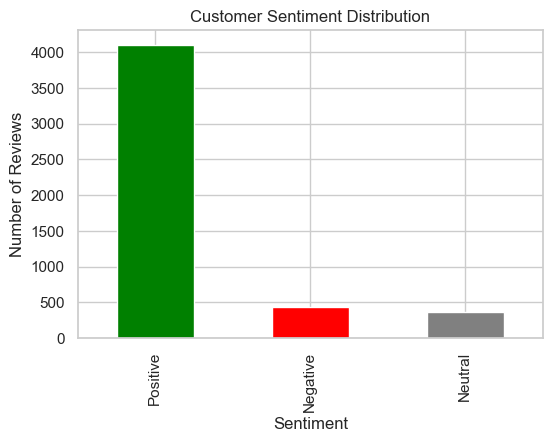

In [9]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar", color=["green","red","gray"])
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()


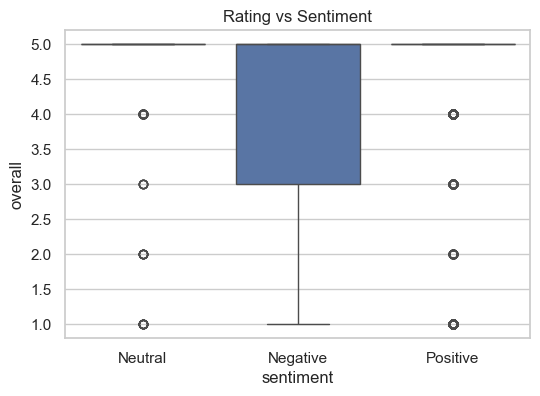

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x="sentiment", y="overall", data=df)
plt.title("Rating vs Sentiment")
plt.show()


## Step 5: Identify Product Improvement Areas

Look closely at negative reviews to find the most common complaint words. These highlight areas the product needs to improve.

In [11]:
negative_reviews = df[df["sentiment"] == "Negative"]["clean_review"]

all_words = " ".join(negative_reviews).split()
word_freq = Counter(all_words)
common_complaints = word_freq.most_common(20)
common_complaints


[('card', 470),
 ('sandisk', 176),
 ('phone', 168),
 ('memory', 132),
 ('one', 132),
 ('cards', 107),
 ('use', 91),
 ('galaxy', 89),
 ('works', 87),
 ('bought', 77),
 ('samsung', 76),
 ('class', 75),
 ('would', 68),
 ('bad', 68),
 ('get', 66),
 ('read', 65),
 ('well', 61),
 ('never', 59),
 ('using', 59),
 ('time', 59)]

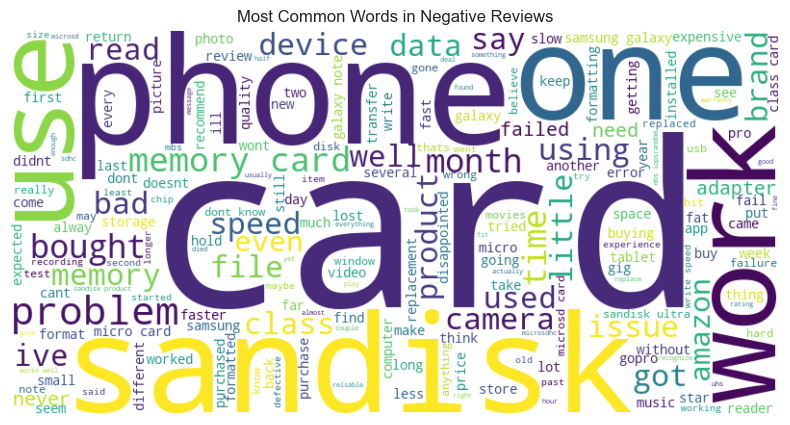

In [12]:
wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(negative_reviews))

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()


## Step 6: Generate Business Insights

Summarize findings that management can act on.

In [13]:
total_reviews = len(df)
positive_pct = (df["sentiment"] == "Positive").mean() * 100
negative_pct = (df["sentiment"] == "Negative").mean() * 100
neutral_pct = (df["sentiment"] == "Neutral").mean() * 100
avg_rating = df["overall"].mean()

print(f"Total Reviews Analyzed: {total_reviews}")
print(f"Positive: {positive_pct:.1f}%")
print(f"Negative: {negative_pct:.1f}%")
print(f"Neutral: {neutral_pct:.1f}%")
print(f"Average Rating: {avg_rating:.2f}")
print("\nTop Complaint Keywords:")
for word, freq in common_complaints[:10]:
    print(f"- {word} ({freq})")


Total Reviews Analyzed: 4914
Positive: 83.5%
Negative: 9.0%
Neutral: 7.5%
Average Rating: 4.59

Top Complaint Keywords:
- card (470)
- sandisk (176)
- phone (168)
- memory (132)
- one (132)
- cards (107)
- use (91)
- galaxy (89)
- works (87)
- bought (77)
